In [1]:
 import pandas as pd

 df = pd.read_csv('Clean_Dataset.csv')

In [2]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## Preprocessing

In [3]:
df = df.drop('Unnamed: 0',axis =1)
df = df.drop('flight',axis = 1)

df['class'] = df['class'].apply(lambda x:1 if x == 'Business' else 0)

In [4]:
df.stops = pd.factorize(df.stops)[0]

In [5]:
df = df.join(pd.get_dummies(df['airline'],dtype=int,prefix='airline')).drop(['airline'],axis=1)
df = df.join(pd.get_dummies(df['source_city'],dtype=int,prefix='source')).drop(['source_city'],axis=1)
df = df.join(pd.get_dummies(df['destination_city'],dtype=int,prefix='desp')).drop(['destination_city'],axis=1)
df = df.join(pd.get_dummies(df['arrival_time'],dtype=int,prefix='arrival')).drop(['arrival_time'],axis=1)
df = df.join(pd.get_dummies(df['departure_time'],dtype=int,prefix='departure')).drop(['departure_time'],axis=1)

In [6]:


df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,departure_Afternoon,departure_Early_Morning,departure_Evening,departure_Late_Night,departure_Morning,departure_Night
0,0,0,2.17,1,5953,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
1,0,0,2.33,1,5953,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
2,0,0,2.17,1,5956,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,2.25,1,5955,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,2.33,1,5955,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
300149,1,1,10.42,49,77105,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
300150,1,1,13.83,49,79099,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
300151,1,1,10.00,49,81585,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

x,y = df.drop('price',axis =1),df.price

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.2) 

In [9]:
reg = RandomForestRegressor(n_jobs = -2)

reg.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
reg.score(x_test,y_test)

0.9817048691352391

In [11]:
import math
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

y_pred = reg.predict(x_test)

print('R2:', r2_score(y_test,y_pred))
print('MAE:', mean_absolute_error(y_test,y_pred))
print('MSE:', mean_squared_error(y_test,y_pred))
print('RMSE:', math.sqrt(mean_squared_error(y_test,y_pred)))

R2: 0.9817048691352391
MAE: 1404.884366916849
MSE: 9424772.940264996
RMSE: 3069.979306162339


Text(0.5, 1.0, 'Actual vs Predicted Flight Price')

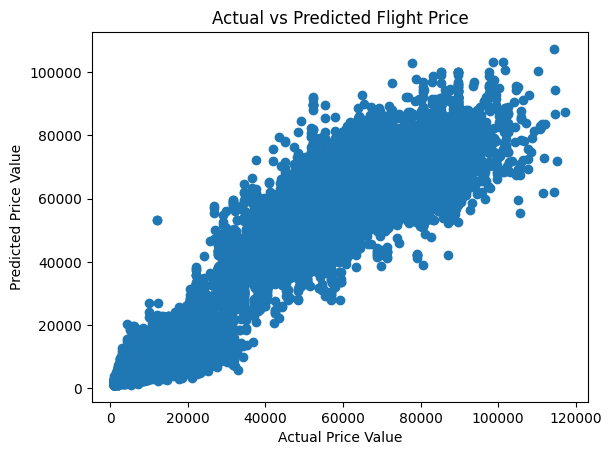

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)
plt.xlabel('Actual Price Value')
plt.ylabel('Predicted Price Value')
plt.title('Actual vs Predicted Flight Price')

In [13]:
importance = dict(zip (reg.feature_names_in_,reg.feature_importances_))
sorted_importance = sorted(importance.items(), key = lambda x: x[1], reverse = True)
sorted_importance

[('class', np.float64(0.8782495654505621)),
 ('duration', np.float64(0.057340733594475356)),
 ('days_left', np.float64(0.018894475671860304)),
 ('airline_Vistara', np.float64(0.005562207048177548)),
 ('airline_Air_India', np.float64(0.004834816887220623)),
 ('source_Delhi', np.float64(0.0036566053993891093)),
 ('desp_Delhi', np.float64(0.0029004215829066247)),
 ('source_Kolkata', np.float64(0.0022380114381051626)),
 ('desp_Kolkata', np.float64(0.002075123291999337)),
 ('source_Mumbai', np.float64(0.002062918092467897)),
 ('desp_Mumbai', np.float64(0.0018651225839505488)),
 ('desp_Hyderabad', np.float64(0.0018029385108816022)),
 ('arrival_Evening', np.float64(0.0016502437656796037)),
 ('stops', np.float64(0.0014866938826204638)),
 ('source_Hyderabad', np.float64(0.0013830502502395268)),
 ('departure_Evening', np.float64(0.0012907830192940494)),
 ('source_Bangalore', np.float64(0.0012694806685644277)),
 ('arrival_Night', np.float64(0.001137770249883285)),
 ('desp_Bangalore', np.float64(0

<BarContainer object of 10 artists>

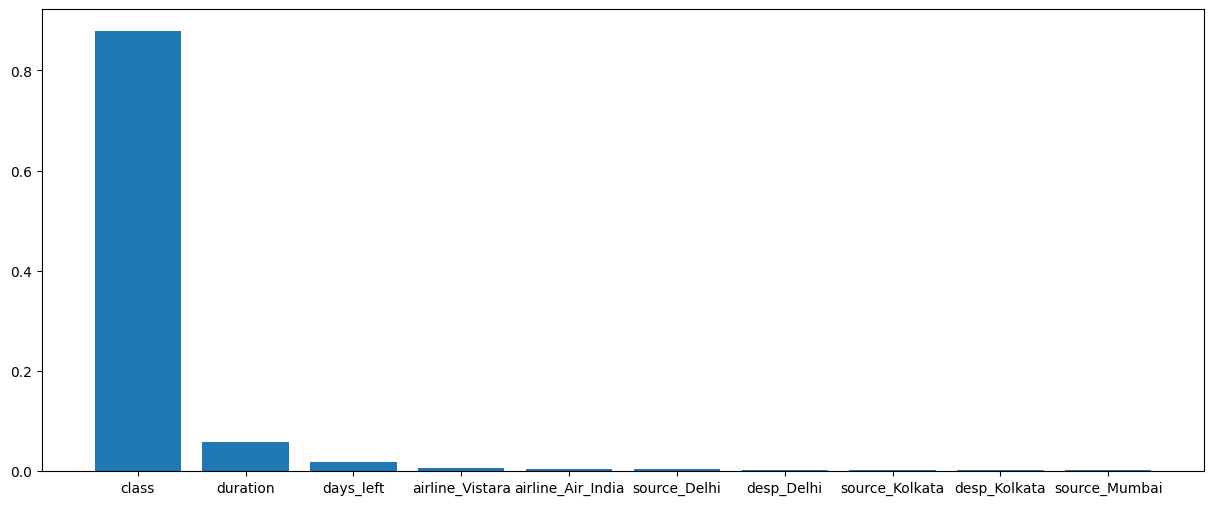

In [14]:
plt.figure(figsize=(15,6))
plt.bar([x[0] for x in sorted_importance[:10]],[ x[1] for x in sorted_importance[:10] ])

In [15]:
# from sklearn.model_selection import GridSearchCV

# reg = RandomForestRegressor(n_jobs=-2)

# param_dict = {
#     'n_estimators' :[100,170,220],
#     'max_depth': [None,10,20],
#     'min_samples_split': [2,5,10],
#     'min_samples_leaf':[2,4],
#     'max_features':['auto','sqrt']
# }

# grid_search = GridSearchCV(reg,param_dict,cv=5)
# grid_search.fit(x_train,y_train)

# best_params = grid_search.best_params_
# best_params

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dict = {
    'n_estimators' :randint(100,300),
    'max_depth': [None,10,20,30,40],
    'min_samples_split': randint(2,11),
    'min_samples_leaf':randint(2,5),
    'max_features':[1.0,'sqrt']
}

reg = RandomForestRegressor(n_jobs=-1)

random_search = RandomizedSearchCV( estimator = reg, param_distributions = param_dict, n_iter=10,cv=3,scoring = 'neg_mean_squared_error', verbose = 2, random_state=42, n_jobs= -1)

random_search.fit(x_train,y_train)

best_regressor = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [23]:
best_regressor.score(x_test,y_test)

0.982169273221078

In [24]:
import math
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

y_pred = best_regressor.predict(x_test)

print('R2:', r2_score(y_test,y_pred))
print('MAE:', mean_absolute_error(y_test,y_pred))
print('MSE:', mean_squared_error(y_test,y_pred))
print('RMSE:', math.sqrt(mean_squared_error(y_test,y_pred)))

R2: 0.982169273221078
MAE: 1456.9237780171356
MSE: 9185534.25463232
RMSE: 3030.764632008286
